# Google Play Store Data Analysis

This project focuses on analyzing Google Play Store applications to understand app trends, ratings, installs, and user engagement.

## Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Loading the Dataset

In [13]:

# Loading the datasets
apps_df = pd.read_csv("apps.csv")
reviews_df = pd.read_csv("user_reviews.csv")

## Previewing the Dataset

In [14]:

# Displaying first 5 rows of apps dataset
apps_df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [15]:

# Displaying first 5 rows of reviews dataset
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [5]:
# Checking the size of both datasets
print("Apps dataset shape:", apps_df.shape)
print("Reviews dataset shape:", reviews_df.shape)

Apps dataset shape: (9659, 14)
Reviews dataset shape: (64295, 5)


## Understanding Dataset Structure

In [6]:
# Checking column names and basic information
apps_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   str    
 2   Category        9659 non-null   str    
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   str    
 7   Type            9659 non-null   str    
 8   Price           9659 non-null   str    
 9   Content Rating  9659 non-null   str    
 10  Genres          9659 non-null   str    
 11  Last Updated    9659 non-null   str    
 12  Current Ver     9651 non-null   str    
 13  Android Ver     9657 non-null   str    
dtypes: float64(2), int64(2), str(10)
memory usage: 1.0 MB


In [ ]:
# Checking missing values in apps dataset
apps_df.isnull().sum()

Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [8]:
# Checking missing values in reviews dataset
reviews_df.isnull().sum()

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

## Initial Data Understanding

This step helped me understand the structure of the datasets before starting the cleaning and visualization process.



In this step, I loaded both datasets and checked their structure, columns, and missing values.  
This helps to understand what kind of cleaning is required before performing analysis.

In [9]:
# Checking the size of both datasets
print("Apps dataset shape:", apps_df.shape)
print("Reviews dataset shape:", reviews_df.shape)

Apps dataset shape: (9659, 14)
Reviews dataset shape: (64295, 5)


# Data Cleaning

In [16]:
# Checking duplicate rows in apps dataset
apps_df.duplicated().sum()

np.int64(0)

In [17]:
# Removing duplicate rows from apps dataset
apps_df = apps_df.drop_duplicates()

In [18]:
# Checking dataset shape after removing duplicates
apps_df.shape

(9659, 14)

In [19]:
# Removing rows where Rating is missing
apps_df = apps_df.dropna(subset=['Rating'])

In [20]:
# Checking missing values after cleaning
apps_df.isnull().sum()

Unnamed: 0           0
App                  0
Category             0
Rating               0
Reviews              0
Size              1169
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          4
Android Ver          2
dtype: int64

## Data Cleaning Summary

In this step, duplicate rows were checked and removed from the dataset. Missing values were also identified to improve data quality before visualization and analysis.

# Column Cleaning and Conversion

In [21]:
# Cleaning Installs column
apps_df['Installs'] = apps_df['Installs'].str.replace(',', '')
apps_df['Installs'] = apps_df['Installs'].str.replace('+', '')
apps_df['Installs'] = apps_df['Installs'].astype(int)

In [22]:
# Displaying cleaned Installs column
apps_df['Installs'].head()

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64

In [23]:
# Cleaning Price column
apps_df['Price'] = apps_df['Price'].str.replace('$', '')
apps_df['Price'] = apps_df['Price'].astype(float)

In [24]:
# Displaying cleaned Price column
apps_df['Price'].head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64

In [25]:
# Converting Reviews column into integer type
apps_df['Reviews'] = apps_df['Reviews'].astype(int)

In [26]:
# Checking updated data types
apps_df.dtypes

Unnamed: 0          int64
App                   str
Category              str
Rating            float64
Reviews             int64
Size              float64
Installs            int64
Type                  str
Price             float64
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object

# Data Visualization

C:\Users\gurur\AppData\Local\Temp\ipykernel_7524\2210918724.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


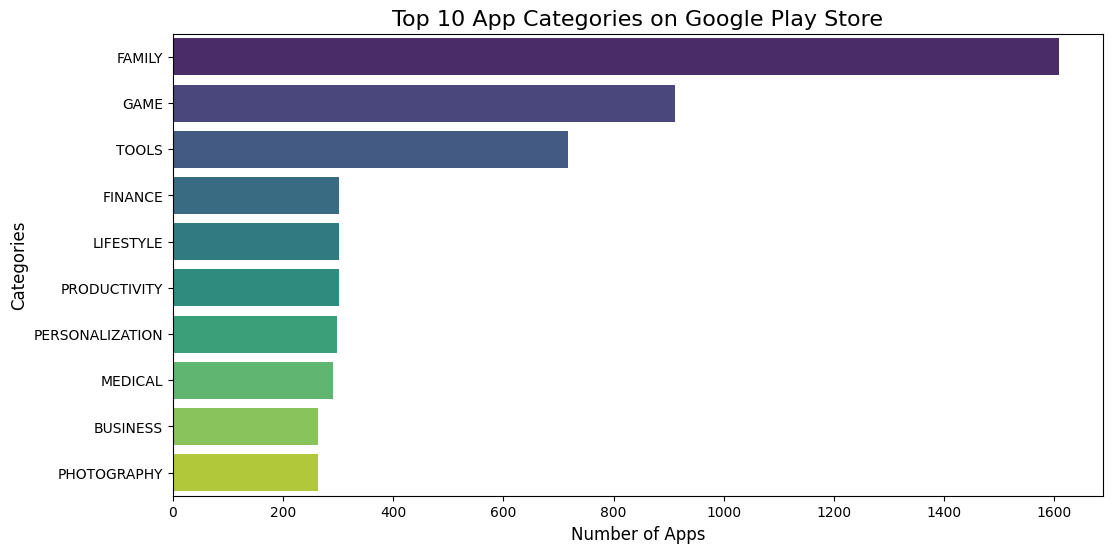

In [28]:


# Top 10 app categories
top_categories = apps_df['Category'].value_counts().head(10)

# Setting figure size
plt.figure(figsize=(12,6))

# Creating colorful barplot
sns.barplot(
    x=top_categories.values,
    y=top_categories.index,
    palette='viridis'
)

# Adding title and labels
plt.title("Top 10 App Categories on Google Play Store", fontsize=16)
plt.xlabel("Number of Apps", fontsize=12)
plt.ylabel("Categories", fontsize=12)

# Showing graph
plt.show()

## Insight

The Family category contains the highest number of applications on the Google Play Store.

## Free vs Paid Apps Distribution

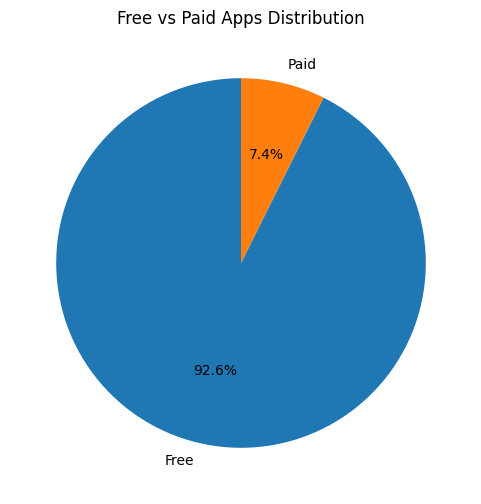

In [29]:
# Counting free and paid apps
app_type = apps_df['Type'].value_counts()

# Creating pie chart
plt.figure(figsize=(6,6))

plt.pie(
    app_type,
    labels=app_type.index,
    autopct='%1.1f%%',
    startangle=90
)

# Adding title
plt.title("Free vs Paid Apps Distribution")

# Display chart
plt.show()

## Insight

Most applications available on the Google Play Store are free apps, while only a small percentage are paid applications.

## Ratings Distribution

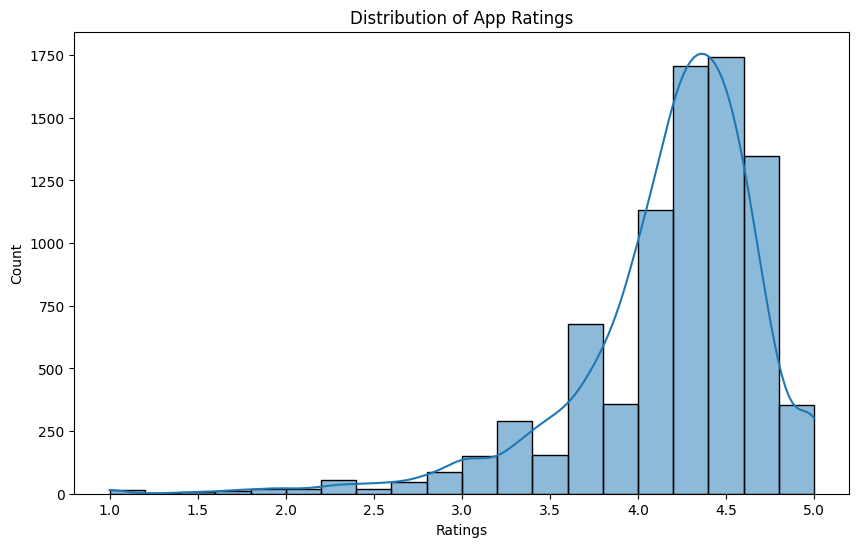

In [30]:
# Creating ratings distribution graph
plt.figure(figsize=(10,6))

sns.histplot(apps_df['Rating'], bins=20, kde=True)

# Adding title and labels
plt.title("Distribution of App Ratings")
plt.xlabel("Ratings")
plt.ylabel("Count")

# Display graph
plt.show()

## Insight

Most applications on the Google Play Store have ratings between 4.0 and 4.5, indicating generally positive user feedback.

## Most Installed App Categories

C:\Users\gurur\AppData\Local\Temp\ipykernel_7524\2920897934.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


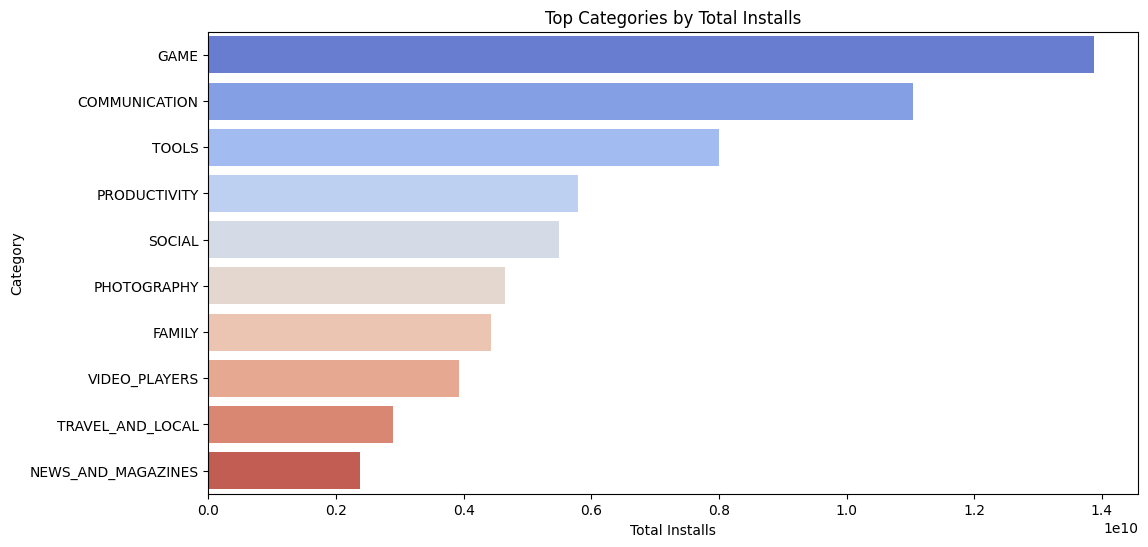

In [31]:
# Grouping categories by installs
category_installs = apps_df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

# Creating bar chart
plt.figure(figsize=(12,6))

sns.barplot(
    x=category_installs.values,
    y=category_installs.index,
    palette='coolwarm'
)

# Adding title and labels
plt.title("Top Categories by Total Installs")
plt.xlabel("Total Installs")
plt.ylabel("Category")

# Display graph
plt.show()

## Insight

Categories such as GAME, COMMUNICATION, and SOCIAL have the highest number of installs on the Google Play Store.

# Conclusion

In this project, I analyzed the Google Play Store dataset to understand app categories, ratings, installs, and app distribution.

Key insights from the analysis:

- Most applications on the Play Store are free apps.
- The Family category contains the highest number of apps.
- Most app ratings fall between 4.0 and 4.5.
- Categories such as GAME and COMMUNICATION have the highest installs.

This project helped me improve my skills in data cleaning, visualization, and extracting meaningful insights from real-world datasets.